# 项目：用逻辑回归预测泰坦尼克号幸存情况

## 分析目标

此数据分析报告的目的是，基于泰坦尼克号乘客的性别和船舱等级等属性，对幸存情况进行逻辑回归分析，从而能利用得到的模型，对未知幸存情况的乘客，根据属性预测是否从沉船事件中幸存。

## 简介

> 泰坦尼克号（英语：RMS Titanic）是一艘奥林匹克级邮轮，于1912年4月首航时撞上冰山后沉没。泰坦尼克号是同级的3艘超级邮轮中的第2艘，与姐妹船奥林匹克号和不列颠号为白星航运公司的乘客们提供大西洋旅行。

> 泰坦尼克号由位于北爱尔兰贝尔法斯特的哈兰·沃尔夫船厂兴建，是当时最大的客运轮船，由于其规模相当一艘现代航空母舰，因而号称“上帝也沉没不了的巨型邮轮”。在泰坦尼克号的首航中，从英国南安普敦出发，途经法国瑟堡-奥克特维尔以及爱尔兰昆士敦，计划横渡大西洋前往美国纽约市。但因为人为错误，于1912年4月14日船上时间夜里11点40分撞上冰山；2小时40分钟后，即4月15日凌晨02点20分，船裂成两半后沉入大西洋，死亡人数超越1500人，堪称20世纪最大的海难事件，同时也是最广为人知的海难之一。

数据集包括两个数据表：`titianic_train.csv`和`titanic_test.csv`。

`titianic_train.csv`记录了超过八百位泰坦尼克号乘客在沉船事件后的幸存情况，以及乘客的相关信息，包括所在船舱等级、性别、年龄、同乘伴侣/同胞数量、同乘父母/孩子数量，等等。

`titanic_test.csv`只包含乘客（这些乘客不在`titianic_train.csv`里）相关信息，此文件可以被用于预测乘客是否幸存。

`titianic_train.csv`每列的含义如下：
- PassengerId：乘客ID
- survival：是否幸存
   - 0	否
   - 1	是
- pclass：船舱等级
   - 1	一等舱
   - 2	二等舱
   - 3  三等舱
- sex：性别
- Age：年龄
- sibsp：同乘伴侣/同胞数量
- parch：同乘父母/孩子数量
- ticket：船票号
- fare：票价金额
- cabin：船舱号
- embarked：登船港口
   - C  瑟堡
   - Q  皇后镇
   - S  南安普敦
   
   
`titianic_test.csv`每列的含义和上面相同，但不具备survival变量的数据，即是否幸存。

## 读取数据

In [1]:
# 引入读取、清理数据及数据可视化所需要的模块或库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

首选创建一个DataFrame变量，取名为original_data，用来存储titianic_train.csv的原始数据。

In [2]:
original_data = pd.read_csv('titanic_train.csv')
original_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 评估、清洗数据

为了将清洗后的数据和原始数据区分，我们再创建一个DataFrame变量，取名为cleaned_data，再将original_data复制的副本赋值给cleaned_data，这样后续与数据清洗的相关步骤均可在cleaned_data上执行。

In [3]:
cleaned_data = original_data.copy()
cleaned_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


数据评估主要分为两个方向：数据整洁度和干净度，即数据结构和数据内容。数据整洁度方面主要评估数据结构是否符合“每行为一个观察值，每列为一个变量，每个单元格只有一个值”的标准。数据干净度主要评估是否含有空缺数据、重复数据、不一致数据、无效和错误数据。

### 数据整洁度

从输出的cleaned_data来看，数据结构符合“每行为一个观察值，每列为一个变量，每个单元格只有一个值”的整洁数据标准。

### 数据干净度

#### 处理空缺数据

首先调用info方法检查数据整体情况。

In [4]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


从输出结果来看，数据中一共有891行观察值。通过非空值数量，可知Age（年龄）、Cabin（船舱号）和Embarked（登陆港口）列存在空缺值，将在后续处理。PassengerId表示旅客ID，数据类型应该是字符串而不是整数，需要做数据类型转换。Survived（是否幸存）、Pclass（船舱等级）、Sex（性别）、Embarked（登陆口岸）属于分类变量，可以将数据类型转化为Category，这样能缩小内存占用空间。

将PassengerId列数据类型转换为字符串。

In [5]:
cleaned_data['PassengerId'] = cleaned_data['PassengerId'].astype(str)

将Survived、Pclass、Sex、Embarked列数据类型转换为Category。

In [6]:
cleaned_data['Survived'] = cleaned_data['Survived'].astype('category')
cleaned_data['Pclass'] = cleaned_data['Pclass'].astype('category')
cleaned_data['Sex'] = cleaned_data['Sex'].astype('category')
cleaned_data['Embarked'] = cleaned_data['Embarked'].astype('category')

In [7]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    str     
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(2), str(4)
memory usage: 59.4 KB


提取Age列为空缺值的行。

In [8]:
cleaned_data.query('Age.isnull()')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


从输出结果来看，共有177行Age为空缺值的观察值，数量约占总体数据的20%，这些观察值中，其他列如Survived、Pclass、Sex、SibSp、Parch等变量仍然是对逻辑回归分析有意义的数据，且数量比较多，因此不建议删除，可以用Age列的平均值进行填充，并在填充后检查Age列空缺值的数量。

In [9]:
cleaned_data['Age'] = cleaned_data['Age'].fillna(cleaned_data['Age'].mean())
len(cleaned_data.query('Age.isnull()'))

0

提取Cabin列为空缺值的行。

In [10]:
cleaned_data.query('Cabin.isnull()')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S


从输出结果来看，一共有687个Cabin（船舱号）列为空缺值的行，由于数量较多，且我们认为船舱号对是该名旅客否幸存的结果无影响，不会被纳入逻辑回归模型的自变量，因此可以将这些行保留。

提取Embarked列为空缺值的行。

In [11]:
cleaned_data.query('Embarked.isnull()')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


从输出结果来看，一共有2行数据的Embarked（登陆口岸）的值为空缺值。我们认为从哪个口岸登陆对该名旅客是否幸存无影响，后续也不会被纳入逻辑回归模型的自变量，因此可以将这2行数据保留。

#### 处理重复数据 

从各变量的含义来看，PassengerId（旅客ID）变量代表旅客身份的唯一表示，不能有重复数据，其他列均允许存在重复数据。因此需要检查PassengerId列是否有重复数据，使用duplicated方法并求和验证。

In [12]:
cleaned_data.duplicated(subset=['PassengerId']).sum()

np.int64(0)

由输出结果可知，PassengerId列不存在重复数据。

#### 处理不一致数据

不一致数据指的是不同值指代同一目标的情况。由各列含义可知，需要调用value_counts方法检查Survived、Sex、Pclass、Embarked这些分类变量是否存在不一致数据。

In [13]:
cleaned_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
cleaned_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [15]:
cleaned_data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [16]:
cleaned_data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

由输出结果可知，以上分类变量均不存在不一致数据。

#### 处理无效和错误数据

调用describe方法查看数据cleaned_data数值变量的统计信息。

In [17]:
cleaned_data.describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,13.002015,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,29.699118,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


从输出结果来看，cleaned_data不存在脱离现实意义的数据。

## 数据整理

In [18]:
cleaned_data.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
635,636,1,2,"Davis, Miss. Mary",female,28.000000,0,0,237668,13.0000,NaN,S
379,380,0,3,"Gustafsson, Mr. Karl Gideon",male,19.000000,0,0,347069,7.7750,NaN,S
250,251,0,3,"Reed, Mr. James George",male,29.699118,0,0,362316,7.2500,NaN,S
726,727,1,2,"Renouf, Mrs. Peter Henry (Lillian Jefferys)",female,30.000000,3,0,31027,21.0000,NaN,S
255,256,1,3,"Touma, Mrs. Darwis (Hanne Youssef Razi)",female,29.000000,0,2,2650,15.2458,NaN,C
376,377,1,3,"Landergren, Miss. Aurora Adelia",female,22.000000,0,0,C 7077,7.2500,NaN,S
408,409,0,3,"Birkeland, Mr. Hans Martin Monsen",male,21.000000,0,0,312992,7.7750,NaN,S
466,467,0,2,"Campbell, Mr. William",male,29.699118,0,0,239853,0.0000,NaN,S
796,797,1,1,"Leader, Dr. Alice (Farnham)",female,49.000000,0,0,17465,25.9292,D17,S
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.000000,0,0,17466,25.9292,D17,S


根据题目中数据分析的目的是：根据数据中乘客的幸存情况和各属性值，做逻辑回归分析，并根据另一个数据集的乘客属性预测事件发生后的幸存情况。数据cleaned_data中SibSp和Parch分别表示同乘伴侣/同胞数量、同乘父母/孩子数量，可以将这两列相加计算出同乘家庭成员的数量，且家庭成员数量对是否幸存可能有显著影响，因此我们创建新的一列series变量，取名为FamilyNum表示家庭成员数量，将这两列相加结果赋值给FamilyNum。

In [19]:
cleaned_data['FamilyNum'] = cleaned_data['SibSp'] + cleaned_data['Parch']
cleaned_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


## 探索数据

利用数据可视化探索数据，可以更直观展示旅客各变量的分布情况以及各变量与幸存情况的关系，能为后续分析提供方向。

In [20]:
# 将色盘颜色调整为pastel
sns.set_palette('pastel')

### 幸存人数分布

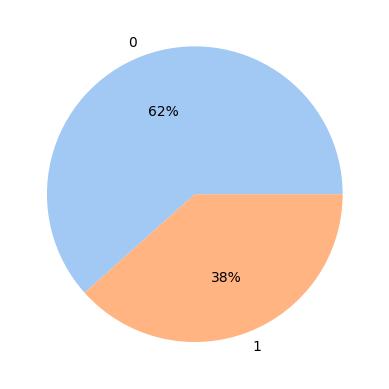

In [21]:
survival_counts = cleaned_data['Survived'].value_counts()
plt.pie(survival_counts, labels=survival_counts.index, autopct='%.0f%%')
plt.show()

由输出的饼图可知，样本中乘客未幸存人数大于幸存人数，说明只有少部分乘客得以逃生。

### 船舱等级与幸存数量

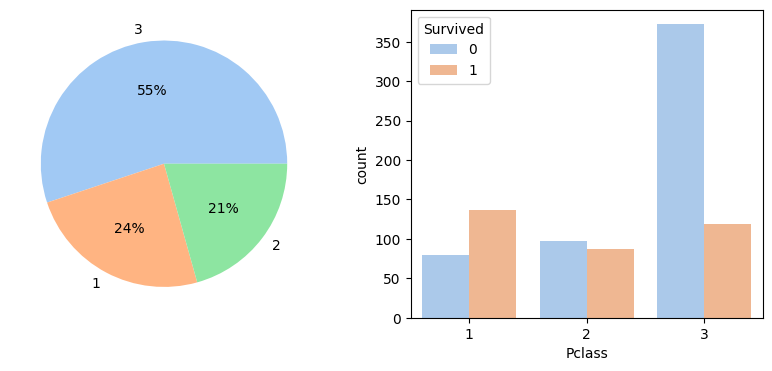

In [22]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
pclass_counts = cleaned_data['Pclass'].value_counts()
axes[0].pie(pclass_counts, labels=pclass_counts.index, autopct='%.0f%%')
sns.countplot(cleaned_data, x="Pclass", hue="Survived", ax=axes[1])
plt.show()

从饼图来看，三等舱数量最多，占55%，二等舱和一等舱数量分别占24%和21%。 
从计数图来看，一等舱的生还人数多于未生还，二等舱生还人数基本等于未生还，三等舱生还人数小于未生还，说明可能船舱等级越高，逃生条件越好。

### 乘客性别与幸存数量

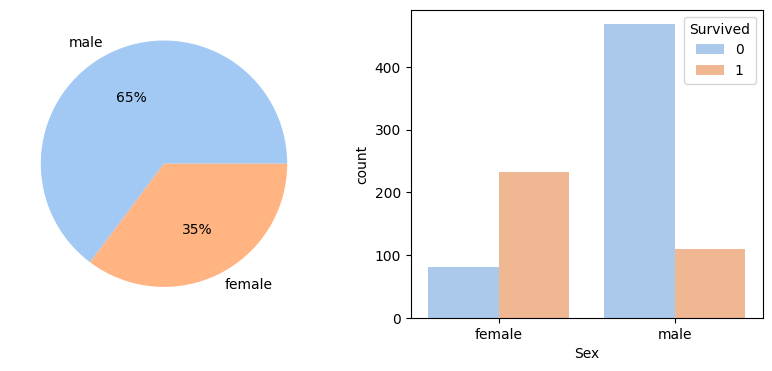

In [23]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sex_counts = cleaned_data['Sex'].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index, autopct='%.0f%%')
sns.countplot(cleaned_data, x="Sex", hue="Survived", ax=axes[1])
plt.show()

从饼图来看，男性旅客数量大于女性旅客，占比65。  
从计数图来看，男性乘客生还比例小于女性乘客，可能是因为很多情况下男性乘客把生还机会让给了女性。

### 乘客年龄和幸存数量

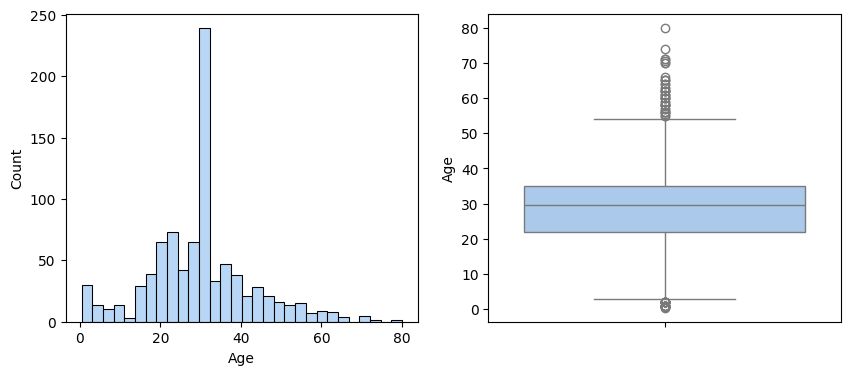

In [24]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.histplot(cleaned_data, x="Age", ax=axes[0])
sns.boxplot(cleaned_data, y="Age", ax=axes[1])
plt.show()

从直方图可知，乘客年龄大多集中在中年。  
从箱型图来看，乘客年龄中位数在30岁左右，也有个别极端值，如年龄较小不到1岁的婴儿，和高龄乘客。

将年龄分布的直方图按是否幸存分类。

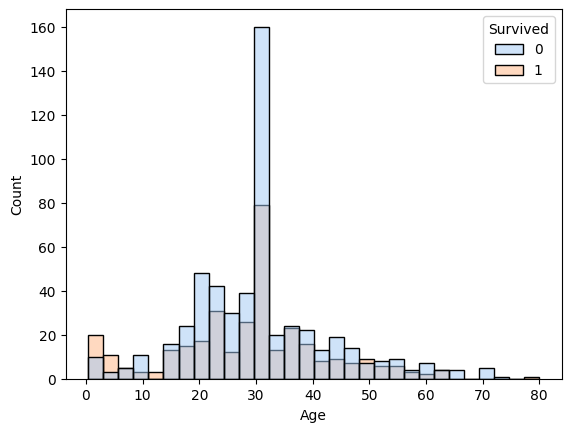

In [25]:
sns.histplot(cleaned_data, x="Age", hue="Survived")
plt.show()

由输出的直方图来看，大部分年龄的乘客都是幸存人数占比小于未幸存人数，但低龄年龄段旅客除外，可能是因为逃生时乘客都遵循妇女儿童先上救生艇的原则。

### 家庭成员数量与是否幸存

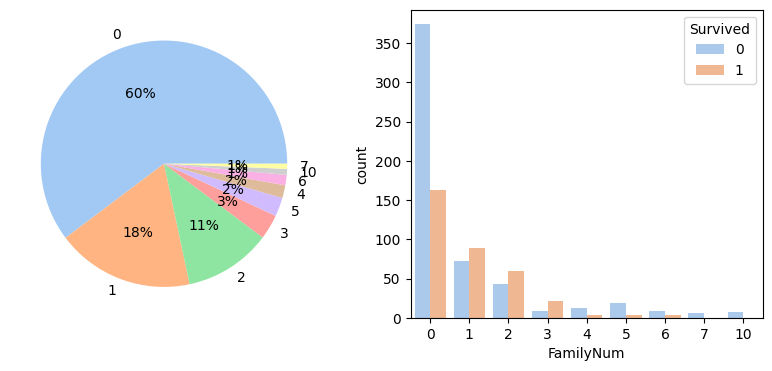

In [26]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
familynum_counts = cleaned_data['FamilyNum'].value_counts()
axes[0].pie(familynum_counts, labels=familynum_counts.index, autopct='%.0f%%')
sns.countplot(cleaned_data, x="FamilyNum", hue="Survived", ax=axes[1])
plt.show()

从饼图来看，有60%的乘客没有同乘家庭成员，有18%的乘客和1位家庭成员一起乘船，有11%的乘客和2位家庭成员一起乘船，有少量乘客同乘的家庭成员数量为3-10。
从计数图来看，没有同乘家庭成员的乘客生还人数小于未生还人数，同乘家庭成员为1-3名的乘客生还人数大于未生还人数，同乘家庭成员在4人以上的乘客生还率很低甚至是0，这也说明这些乘客在逃生时可能因为需要同时去营救一起乘船的其他家人而失去了生还的机会。

### 票价分布

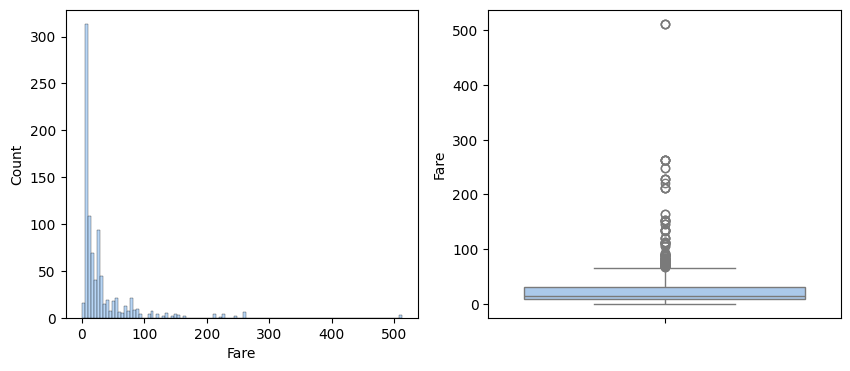

In [27]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.histplot(cleaned_data, x="Fare", ax=axes[0])
sns.boxplot(cleaned_data, y="Fare", ax=axes[1])
plt.show()

从直方图来看，票价集中在10美元左右，有少量0美元价格的票，可能以赠送形式发放的。从箱型图来看，票价中位数大概在10美元，有个别极高值拉高了票价。

将票价直方图按是否幸存分类。

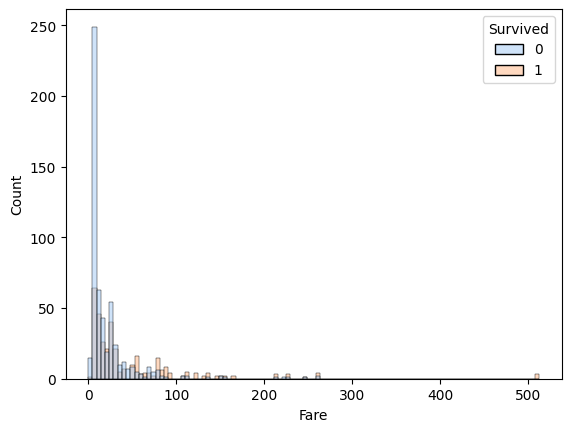

In [28]:
sns.histplot(cleaned_data, x="Fare", hue="Survived")
plt.show()

从输出结果来看，拥有低票价乘客的生还率低于拥有高票价乘客的生还率，说明票价越高代表船舱等级越高，逃生条件越便利。

### 登船港口分布

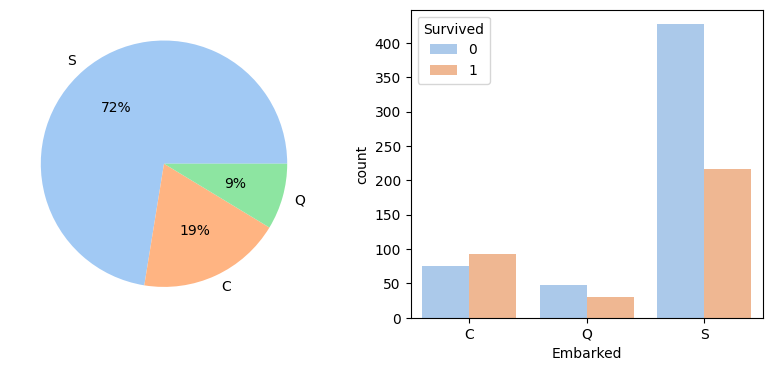

In [29]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
embarked_counts = cleaned_data['Embarked'].value_counts()
axes[0].pie(embarked_counts, labels=embarked_counts.index, autopct='%.0f%%')
sns.countplot(cleaned_data, x="Embarked", hue="Survived", ax=axes[1])
plt.show()

从饼图来看，在南安普顿登船的乘客最多，占比72%，在瑟堡登船人数占比19%，在皇后镇登船人数最少，占比9%。  
从计数图来看，在瑟堡登船的乘客生还率较高，在南岸普顿登船的乘客生还率最低。

## 逻辑回归分析和预测

本次分析的目的是根据数据中乘客属性和幸存情况做逻辑回归分析，并用创建的逻辑回归分析模型预测未知幸存的乘客是否幸存。

在进行逻辑回归分析之前，我们先创建一个新的DataFrame变量，取名为lr_data，并将原始数据cleaned_data复制的副本赋值给它，因为在逻辑回归时还要对数据集做引入虚拟变量等准备工作，这些相关操作后续都可以在lr_data上执行。

In [30]:
lr_data = cleaned_data.copy()
lr_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


移除对幸存与否影响不大的变量PassengerId、Name、Ticket、Cabin、Embarked。

In [31]:
lr_data = lr_data.drop(['PassengerId','Name','Ticket','Cabin','Embarked'], axis=1)
lr_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilyNum
0,0,3,male,22.0,1,0,7.2500,1
1,1,1,female,38.0,1,0,71.2833,1
2,1,3,female,26.0,0,0,7.9250,0
3,1,1,female,35.0,1,0,53.1000,1
4,0,3,male,35.0,0,0,8.0500,0


In [32]:
# 引用逻辑回归分析需要的模块
import statsmodels.api as sm

### 引入虚拟变量

Pclass（船舱等级）、Sex（性别）为回归模型潜在的自变量，但由于是分类变量无法纳入模型，因此需要将它们替换成虚拟变量，且用0和1表示是否属于该分类。

In [33]:
lr_data = pd.get_dummies(lr_data, columns=['Pclass','Sex'], dtype=int, drop_first=True)
lr_data.head()

,Survived,Age,SibSp,Parch,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,0,22.0,1,0,7.2500,1,0,1,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,1,26.0,0,0,7.9250,0,0,1,0
3,1,35.0,1,0,53.1000,1,0,0,0
4,0,35.0,0,0,8.0500,0,0,1,1


### 提取模型的因变量和自变量

由于本次分析的目的是对乘客幸存情况做预测，因此模型的自变量是Survived(是否幸存)那一列，数据里的其他变量暂时全部纳入因变量，后续还需要检查它们的相关性。

In [34]:
# 提取自变量y
y = lr_data['Survived']
# 提取因变量X
X = lr_data.drop(['Survived'], axis=1)

In [35]:
X.head()

,Age,SibSp,Parch,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,22.0,1,0,7.2500,1,0,1,1
1,38.0,1,0,71.2833,1,0,0,0
2,26.0,0,0,7.9250,0,0,1,0
3,35.0,1,0,53.1000,1,0,0,0
4,35.0,0,0,8.0500,0,0,1,1


需要检查X各变量之间的相关系数，当相关系数绝对值大于0.8时，便认为两个变量之间存在共线性问题，需要去除掉其中一个。

In [36]:
X.corr().abs()

,Age,SibSp,Parch,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
Age,1.000000,0.232625,0.179191,0.091566,0.248512,0.006589,0.281004,0.084153
SibSp,0.232625,1.000000,0.414838,0.159651,0.890712,0.055932,0.092548,0.114631
Parch,0.179191,0.414838,1.000000,0.216225,0.783111,0.000734,0.015790,0.245489
Fare,0.091566,0.159651,0.216225,1.000000,0.217138,0.118557,0.413333,0.182333
FamilyNum,0.248512,0.890712,0.783111,0.217138,1.000000,0.038594,0.071142,0.200988
Pclass_2,0.006589,0.055932,0.000734,0.118557,0.038594,1.000000,0.565210,0.064746
Pclass_3,0.281004,0.092548,0.015790,0.413333,0.071142,0.565210,1.000000,0.137143
Sex_male,0.084153,0.114631,0.245489,0.182333,0.200988,0.064746,0.137143,1.000000


In [37]:
X.corr().abs() > 0.8

,Age,SibSp,Parch,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
Age,True,False,False,False,False,False,False,False
SibSp,False,True,False,False,True,False,False,False
Parch,False,False,True,False,False,False,False,False
Fare,False,False,False,True,False,False,False,False
FamilyNum,False,True,False,False,True,False,False,False
Pclass_2,False,False,False,False,False,True,False,False
Pclass_3,False,False,False,False,False,False,True,False
Sex_male,False,False,False,False,False,False,False,True


按照相关系数大于0.8为标准筛选出来的结果看，SibSp和FamilyNum符合条件，因此这两个变量具有强相关性，这也在情理之中，因为FamilyNum是SibSp和Parch相加后的结果。  
再看FamilyNum和Parch，它们的相关系数为0.783111，比较接近0.8，也有较强的相关性，因此需要删除SibSp和Parch这两个变量。

In [38]:
X = X.drop(['SibSp','Parch'], axis=1)
X

,Age,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,22.000000,7.2500,1,0,1,1
1,38.000000,71.2833,1,0,0,0
2,26.000000,7.9250,0,0,1,0
3,35.000000,53.1000,1,0,0,0
4,35.000000,8.0500,0,0,1,1
...,...,...,...,...,...,...
886,27.000000,13.0000,0,1,0,1
887,19.000000,30.0000,0,0,0,0
888,29.699118,23.4500,3,0,1,0
889,26.000000,30.0000,0,0,0,1


### 为模型添加截距

为自变量X添加一列常量，作为逻辑回归方程的截距。

In [39]:
X = sm.add_constant(X)
X

,const,Age,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,1.0,22.000000,7.2500,1,0,1,1
1,1.0,38.000000,71.2833,1,0,0,0
2,1.0,26.000000,7.9250,0,0,1,0
3,1.0,35.000000,53.1000,1,0,0,0
4,1.0,35.000000,8.0500,0,0,1,1
...,...,...,...,...,...,...,...
886,1.0,27.000000,13.0000,0,1,0,1
887,1.0,19.000000,30.0000,0,0,0,0
888,1.0,29.699118,23.4500,3,0,1,0
889,1.0,26.000000,30.0000,0,0,0,1


### 建立模型并拟合

In [40]:
# 建立模型并拟合
result = sm.Logit(y, X).fit()
# 对拟合结果进行汇总展示
result.summary()

Optimization terminated successfully.
         Current function value: 0.443547
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      884
Method:                           MLE   Df Model:                            6
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.3339
Time:                        11:41:05   Log-Likelihood:                -395.20
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.786e-82
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8097      0.445      8.568      0.000       2.938       4.681
Age           -0.0388      0.008     -4.963      0.000      -0.054      -0.023
Fare           0.0032      0.002      1.311      0.190      -0.002       0.008
FamilyNum     -0.2430      0.068     -3.594      0.000      -0.376      -0.110
Pclass_2      -1.0003      0.293     -3.416      0.001      -1.574      -0.426
Pclass_3      -2.1324      0.289     -7.373      0.000      -2.699      -1.566
Sex_male      -2.7759      0.199    -13.980      0.000      -3.165      -2.387
==============================================================================
"""

我们把显著水平设定为0.05。  
观察展示结果，其中Fare（票价）变量的P值为0.190，大于显著水平，说明票价对于是否幸存无显著影响，因此需要将Fare（票价）变量从自变量X中删除再重新纳入模型拟合。

In [41]:
X = X.drop(['Fare'], axis=1)
X

,const,Age,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,1.0,22.000000,1,0,1,1
1,1.0,38.000000,1,0,0,0
2,1.0,26.000000,0,0,1,0
3,1.0,35.000000,1,0,0,0
4,1.0,35.000000,0,0,1,1
...,...,...,...,...,...,...
886,1.0,27.000000,0,1,0,1
887,1.0,19.000000,0,0,0,0
888,1.0,29.699118,3,0,1,0
889,1.0,26.000000,0,0,0,1


将自变量X、因变量y纳入逻辑回归模型重新拟合。

In [42]:
result = sm.Logit(y, X).fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.444623
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      885
Method:                           MLE   Df Model:                            5
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.3323
Time:                        11:41:06   Log-Likelihood:                -396.16
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 4.927e-83
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0620      0.404     10.049      0.000       3.270       4.854
Age           -0.0395      0.008     -5.065      0.000      -0.055      -0.024
FamilyNum     -0.2186      0.065     -3.383      0.001      -0.345      -0.092
Pclass_2      -1.1798      0.261     -4.518      0.000      -1.692      -0.668
Pclass_3      -2.3458      0.242     -9.676      0.000      -2.821      -1.871
Sex_male      -2.7854      0.198    -14.069      0.000      -3.173      -2.397
==============================================================================
"""

从输出结果来看，已经没有对因变量是否幸存没有显著影响的变量了。  
另外从逻辑回归方程的各个系数可知，以下变量的增加或存在会降低乘客生还的概率：Age（年龄）、FamilyNum（家庭成员数量）、Pclass_2（属于二等舱）、Pclass_3（属于三等舱），Sex_male（性别为男性）。

通过计算自然常数次方，我们可以进一步理解各自变量各自变量系数的的意义。

In [43]:
# Age
np.exp(-0.0395)

np.float64(0.9612699539905982)

说明年龄每增长1岁，逃生的概率下降约4%。

In [44]:
# FamilyNum
np.exp(-0.2186)

np.float64(0.803643111115195)

说明同乘的家庭成员每多1位，逃生的概率下降约20%

In [45]:
# Pclass_2
np.exp(-1.1798)

np.float64(0.30734020049483596)

说明二等舱比一等舱逃生概率下降约70%。

In [46]:
# Pclass_3
np.exp(-2.3458)

np.float64(0.09577055503172162)

说明三等舱比一等舱逃生概率下降约91%。

In [47]:
# Sex_male
np.exp(-2.7854)

np.float64(0.061704402333015156)

说明男性乘客逃生的概率相较女性乘客下降约94%。

以上自然常数次方的计算结果说明：  
- 年龄越小的乘客逃生概率越高
- 家庭成员多的乘客逃生概率较低
- 船舱等级越高的乘客逃生概率越高
- 女性乘客逃生概率高于男性乘客

这个结论背后可能的原因是逃生时乘客遵循女士小孩优先的原则，而船舱等级越高，乘客身份越最贵，逃生的优先级越高，而家庭成员多的乘客，可能因为需要在逃生的同时营救其他家庭成员，所以错过了逃生机会。

### 利用逻辑回归模型预测

本次分析的目的是利用得到的逻辑回归模型预测titanic_test.csv中的乘客是否幸存。

#### 读取数据

In [48]:
test_data = pd.read_csv('titanic_test.csv')
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


#### 整理数据

我们需要创建一个新的DataFrame变量，取名为predict_data，并将test_data复制的副本赋值给它，这样做的原因是需要预测的数据变量必须与模型变量一致，因此需要将读取到的需要预测的数据做一些整理和调整，比如删除不需要的变量和引入分类变量，因此后续所有相关步骤都将在新创建的predict_data上进行。

In [49]:
predict_data = test_data.copy()
predict_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


在整理数据前，我们还需要检查数据是否有是否有空缺值，因为逻辑回归模型不允许数据中有空缺值。

In [50]:
predict_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


由输出结果来看，Age、Fare、Cabin列含有空缺值。由于Fare和Cabin不被纳入回归模型的自变量，因此存在空缺值并不影响预测结果。而Age（年龄）属于模型的自变量，不允许由空缺值，可以用这一列的平均值来填充空缺值，然后检查该列空缺值的个数和是否为0。

In [51]:
predict_data['Age'] = predict_data['Age'].fillna(predict_data['Age'].mean())
predict_data['Age'].isnull().sum()

np.int64(0)

查看一下模型的变量。

In [52]:
result.params

const        4.061982
Age         -0.039495
FamilyNum   -0.218627
Pclass_2    -1.179763
Pclass_3    -2.345823
Sex_male    -2.785398
dtype: float64

回归模型的因变量中包含FamilyNum变量，这是SibSp和Parch两个变量相加后的结果，因此我们需要按照此步骤在predict_data增加一列变量FamilyNum，另外还要删除PassengerId、Name、SibSp、Parch、Ticket、Fare、Cabin、Embarked这些不属于模型因变量的列。

In [53]:
predict_data['FamilyNum'] = predict_data['SibSp'] + predict_data['Parch']
predict_data = predict_data.drop(['PassengerId','Name','SibSp','Parch','Ticket','Fare','Cabin','Embarked'], axis=1)
predict_data.head()

,Pclass,Sex,Age,FamilyNum
0,3,male,34.5,0
1,3,female,47.0,1
2,2,male,62.0,0
3,3,male,27.0,0
4,3,female,22.0,2


由于Pclass（船舱等级）、Sex（性别）都属于分类变量，因此需要将它们的数据类型都转化为Category，并且让程序知道每列所有可能的分类变量值，这样在后续给predict_data引入分类变量的时候就不会出现漏掉某个分类变量值的情况。

In [54]:
predict_data['Pclass'] = pd.Categorical(predict_data['Pclass'], categories=['1','2','3'])
predict_data['Sex'] = pd.Categorical(predict_data['Sex'], categories=['female', 'male'])
predict_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Pclass     0 non-null      category
 1   Sex        418 non-null    category
 2   Age        418 non-null    float64 
 3   FamilyNum  418 non-null    int64   
dtypes: category(2), float64(1), int64(1)
memory usage: 7.6 KB


C:\Users\wesso\AppData\Local\Temp\ipykernel_16128\3300373506.py:1: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  predict_data['Pclass'] = pd.Categorical(predict_data['Pclass'], categories=['1','2','3'])


转换完数据类型后，将Pclass（船舱等级）、Sex（性别）两列替换成虚拟变量，并用0和1表示是否属于这个分类。

In [55]:
predict_data = pd.get_dummies(predict_data, dtype=int, columns=['Pclass','Sex'], drop_first=True)
predict_data.head()

,Age,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,34.5,0,0,0,1
1,47.0,1,0,0,0
2,62.0,0,0,0,1
3,27.0,0,0,0,1
4,22.0,2,0,0,0


给由于模型包含截距，所以需要给predict_data引入一个常量。

In [56]:
predict_data = sm.add_constant(predict_data)
predict_data.head()

,const,Age,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,1.0,34.5,0,0,0,1
1,1.0,47.0,1,0,0,0
2,1.0,62.0,0,0,0,1
3,1.0,27.0,0,0,0,1
4,1.0,22.0,2,0,0,0


确认predict_data各变量和模型一致后，调用模型的predict函数预测乘客幸存概率。

In [57]:
predict_result = result.predict(predict_data)
predict_result

0      0.478514
1      0.879434
2      0.236473
3      0.552361
4      0.940242
         ...   
413    0.520230
414    0.925647
415    0.439306
416    0.520230
417    0.411858
Length: 418, dtype: float64

因此我们获得了titanic_test.csv里乘客在泰坦尼克号事件发生后幸存的概率。我们把概率大于等于0.5预测为幸存，把概率小于0.5预测为遇难，筛选后的最终结果为：

In [58]:
predict_result >= 0.5

0      False
1       True
2      False
3       True
4       True
       ...  
413     True
414     True
415    False
416     True
417    False
Length: 418, dtype: bool